In [50]:
import os.path
import numpy as np
import matplotlib.pyplot as plt
import pretty_midi

In [51]:
%%capture
%run ./midi_to_matrix.ipynb

In [68]:
xml_dir = 'xml_features'

# file = 'bach_fugue_bwv_846.mid'
# xml = 'bach_fugue_bwv_846.musicxml.npz'

file = 'schumann_arabeske_park.mid'
xml = 'schumann_arabeske.musicxml.npz'

# file = 'brahms_Shilyaev03.mid'
# xml = 'brahms.musicxml.npz'

# file = 'liszt_concert_etude_s145_Kleisen03.mid'
# xml = 'liszt_concert_etude_s145_1.musicxml.npz'

xml_filepath = os.path.join(xml_dir, xml)

xml_data = np.load(xml_filepath)
xml_features = xml_data['roll']
measure_boundaries = xml_data['measure_boundaries']

32


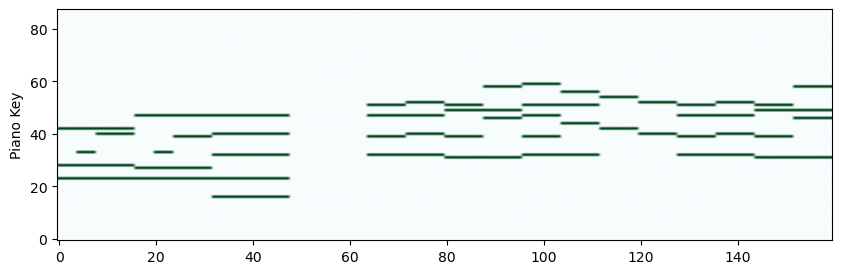

In [93]:
start = 1268
num_measures = 5
measure_len = measure_boundaries[num_measures+1] - measure_boundaries[num_measures]
print(measure_len)
plt.figure(figsize=(10,3))
plt.imshow(xml_features[:,start:start+num_measures*measure_len], cmap = 'BuGn', origin = 'lower', aspect='auto')
plt.ylabel('Piano Key')
plt.show()

In [94]:
excerpt_roll = xml_features[:,start:start+num_measures*measure_len]
excerpt_measure_boundaries = np.array(range(measure_len,measure_len*4,measure_len))

In [95]:
np.savez(os.path.join('xml_features', 'earlyexcerpt'+xml), roll=excerpt_roll, measure_boundaries=excerpt_measure_boundaries)

In [100]:
xml_dir = 'xml_features'
dir = 'midi'

# file = 'bach_fugue_bwv_846.mid'
# xml = 'bach_fugue_bwv_846.musicxml.npz'

file = 'pauseexcerptschumann_arabeske_park.mid'
xml = 'pauseexcerptschumann_arabeske.musicxml.npz'

# file = 'brahms_Shilyaev03.mid'
# xml = 'brahms.musicxml.npz'

# file = 'liszt_concert_etude_s145_Kleisen03.mid'
# xml = 'liszt_concert_etude_s145_1.musicxml.npz'


xml_filepath = os.path.join(xml_dir, xml)
filepath = os.path.join(dir, file)

xml_data = np.load(xml_filepath)
xml_features = xml_data['roll']
xml_frames = xml_data['measure_boundaries'][-1]

In [101]:
midi_frames = 0
fs = 1
roll = midi_to_matrix(filepath, fs)

while midi_frames < xml_frames*0.9:
    fs += 1
    midi_frames = roll.shape[1]
    roll = midi_to_matrix(filepath, fs)

32


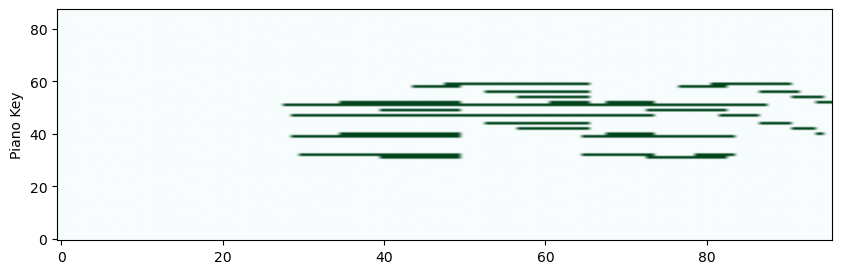

In [102]:
print(measure_len)
plt.figure(figsize=(10,3))
plt.imshow(roll, cmap = 'BuGn', origin = 'lower', aspect='auto')
plt.ylabel('Piano Key')
plt.show()

In [103]:
np.savez(os.path.join('midi_features', file), roll=roll, fs=fs)